In [1]:
# Thread-limit guard for shared HPC/login environments.
# Run this cell first, then restart kernel + Run All.
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

print("Thread limits set: OPENBLAS/OMP/MKL/NUMEXPR/VECLIB = 1")

Thread limits set: OPENBLAS/OMP/MKL/NUMEXPR/VECLIB = 1


In [6]:
import sys
from pathlib import Path

import spiceypy

print(sys.executable)
print("SPICE Version:", spiceypy.tkvrsn("TOOLKIT"))

/home/kaushim07/miniforge3/envs/photomc_env/bin/python
SPICE Version: CSPICE_N0067


In [3]:
!hostname

login.curta.zedat.fu-berlin.de


# Spatial Sanity Check
Load one geometry parquet file, reconstruct $1024 \times 1024$ grids, and compare I/F against incidence angle.
If dark I/F regions align with high incidence ($i \to 90^\circ$), SPICE-to-DTM alignment is consistent.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

geom_dir = Path("../data/04_geometry_tables")
parquet_files = sorted(geom_dir.glob("*_geometry.parquet"))
if not parquet_files:
    raise FileNotFoundError("No geometry parquet files found in ../data/04_geometry_tables")

# Pick the parquet with the most rows so sanity plots use the richest output available.
best_rows = -1
parquet_path = None
df = None
for candidate in parquet_files:
    tmp = pd.read_parquet(candidate)
    if len(tmp) > best_rows:
        best_rows = len(tmp)
        parquet_path = candidate
        df = tmp

print(f"Loaded: {parquet_path.name}")
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Files discovered: {len(parquet_files)}")
if len(df) == 0:
    print("WARNING: all geometry parquet files are empty (0 rows).")

In [ ]:
import numpy as np


def pick_col(dataframe, candidates):
    for col in candidates:
        if col in dataframe.columns:
            return col
    raise KeyError(f"None of these columns found: {candidates}")


iof_col = pick_col(df, ["iof", "I/F", "if", "reflectance"])
inc_col = pick_col(df, ["incidence", "incidence_deg", "incidence [deg]", "i_deg"])

height, width = 1024, 1024
geometry_empty = len(df) == 0

if geometry_empty:
    # Keep notebook runnable and explicit when parquet has no valid intercept rows.
    iof_grid = np.full((height, width), np.nan, dtype=np.float32)
    inc_grid = np.full((height, width), np.nan, dtype=np.float32)
    covered = 0
else:
    if {"pixel_y", "pixel_x"}.issubset(df.columns):
        # Sparse-safe rebuild: write values to their pixel coordinates and leave missing as NaN.
        iof_grid = np.full((height, width), np.nan, dtype=np.float32)
        inc_grid = np.full((height, width), np.nan, dtype=np.float32)

        px = df["pixel_x"].to_numpy(dtype=int)
        py = df["pixel_y"].to_numpy(dtype=int)
        valid = (px >= 0) & (px < width) & (py >= 0) & (py < height)

        iof_grid[py[valid], px[valid]] = df[iof_col].to_numpy(dtype=np.float32)[valid]
        inc_grid[py[valid], px[valid]] = df[inc_col].to_numpy(dtype=np.float32)[valid]
    else:
        # Dense fallback for legacy files without pixel coordinates.
        expected = height * width
        if len(df) != expected:
            raise ValueError(
                f"Parquet has {len(df)} rows without pixel_x/pixel_y; cannot reshape to 1024x1024."
            )
        iof_grid = df[iof_col].to_numpy(dtype=np.float32).reshape(height, width)
        inc_grid = df[inc_col].to_numpy(dtype=np.float32).reshape(height, width)

    covered = np.isfinite(inc_grid).sum()

print(f"Pixels with geometry: {covered:,} / {height * width:,} ({covered / (height * width):.1%})")

## Opposition Effect Check (Li et al. 2013 style)
Combine all valid pixels from the three geometry parquet files, then inspect how I/F varies with phase angle using a 2D density plot and a 1 degree binned mean trend line.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axes[0].imshow(iof_grid, cmap="gray", origin="upper")
axes[0].set_title("I/F image")
axes[0].set_xlabel("pixel_x")
axes[0].set_ylabel("pixel_y")
cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("I/F")

im1 = axes[1].imshow(inc_grid, cmap="magma", origin="upper", vmin=0, vmax=90)
axes[1].set_title("Incidence angle map")
axes[1].set_xlabel("pixel_x")
axes[1].set_ylabel("pixel_y")
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Incidence (deg)")

title_suffix = " (EMPTY GEOMETRY TABLE)" if geometry_empty else ""
plt.suptitle(f"Spatial Sanity Check: {parquet_path.name}{title_suffix}", y=1.02)
plt.show()

if geometry_empty:
    print("No geometry values available to compare yet. Re-run geometry generation for this image.")
else:
    print("Check: dark I/F shadows should line up with high-incidence areas (near 90 deg).")

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

geom_dir = Path("../data/04_geometry_tables")
parquet_paths = sorted(geom_dir.glob("*_geometry.parquet"))
if len(parquet_paths) < 3:
    raise FileNotFoundError(
        f"Expected 3 geometry parquet files, found {len(parquet_paths)} in {geom_dir}"
    )

frames = []
for p in parquet_paths:
    dfi = pd.read_parquet(p, columns=["iof", "phase"])
    # Keep only physically meaningful, finite values.
    dfi = dfi[np.isfinite(dfi["iof"]) & np.isfinite(dfi["phase"])]
    dfi = dfi[(dfi["iof"] > 0.0) & (dfi["phase"] >= 0.0) & (dfi["phase"] <= 180.0)]
    dfi = dfi.copy()
    dfi["source"] = p.stem
    frames.append(dfi)

df_all = pd.concat(frames, ignore_index=True)
print(f"Combined valid pixels: {len(df_all):,}")
print(f"Phase range: {df_all.phase.min():.3f} to {df_all.phase.max():.3f} deg")
print(f"I/F range: {df_all.iof.min():.5f} to {df_all.iof.max():.5f}")

# 1 degree phase bins and mean I/F trend.
df_all["phase_bin_deg"] = np.floor(df_all["phase"]).astype(int)
trend = (
    df_all.groupby("phase_bin_deg", as_index=False)
    .agg(mean_iof=("iof", "mean"), n=("iof", "size"))
    .sort_values("phase_bin_deg")
)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

hb = ax.hexbin(
    df_all["phase"],
    df_all["iof"],
    gridsize=140,
    mincnt=3,
    bins="log",
    cmap="viridis",
)
cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("log10(pixel count)")

ax.plot(
    trend["phase_bin_deg"] + 0.5,
    trend["mean_iof"],
    color="crimson",
    linewidth=2.2,
    label="Mean I/F per 1 degree phase bin",
)

ax.set_title("Vesta Opposition Effect Diagnostic")
ax.set_xlabel("Phase angle alpha (deg)")
ax.set_ylabel("I/F")
ax.set_xlim(max(0, df_all["phase"].min() - 1), min(180, df_all["phase"].max() + 1))
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.show()

low_mask = trend["phase_bin_deg"] <= 10
if low_mask.sum() > 2:
    m, b = np.polyfit(trend.loc[low_mask, "phase_bin_deg"], trend.loc[low_mask, "mean_iof"], 1)
    print(f"Near-opposition slope (0-10 deg): {m:.6f} I/F per degree")
    if m < 0:
        print("PASS: Mean I/F decreases with phase; brightness rises toward opposition.")
    else:
        print("CHECK: Trend near opposition is not decreasing; inspect bins and coverage.")
else:
    print("Not enough low-phase bins (<=10 deg) for a strong opposition-slope check.")

## Disk-Function Correction: Lommel-Seeliger
Apply a Lommel-Seeliger correction to reduce topographic illumination effects and isolate intrinsic regolith reflectance.
Formula used: $R_{LS} = (I/F) \times (\cos i + \cos e) / \cos i$, with angles converted to radians.

In [ ]:
# Load all valid pixels needed for disk-function correction
geom_dir = Path("../data/04_geometry_tables")
parquet_paths = sorted(geom_dir.glob("*_geometry.parquet"))
if len(parquet_paths) < 3:
    raise FileNotFoundError(
        f"Expected 3 geometry parquet files, found {len(parquet_paths)} in {geom_dir}"
    )

frames_ls = []
for p in parquet_paths:
    dfi = pd.read_parquet(p, columns=["iof", "phase", "incidence", "emission"])
    dfi = dfi[
        np.isfinite(dfi["iof"])
        & np.isfinite(dfi["phase"])
        & np.isfinite(dfi["incidence"])
        & np.isfinite(dfi["emission"])
    ]
    dfi = dfi[(dfi["iof"] > 0.0) & (dfi["phase"] >= 0.0) & (dfi["phase"] <= 180.0)]
    frames_ls.append(dfi)

df_ls = pd.concat(frames_ls, ignore_index=True)

# Convert angles (deg -> rad) and compute cosines.
i_rad = np.deg2rad(df_ls["incidence"].to_numpy(dtype=np.float64))
e_rad = np.deg2rad(df_ls["emission"].to_numpy(dtype=np.float64))
mu0 = np.cos(i_rad)
mu = np.cos(e_rad)

# Stability cuts: remove limb/grazing illumination where LS correction blows up.
# These cuts preserve physically meaningful disk-function behavior.
valid_geom = (
    (mu0 > 0.10)
    & (mu > 0.0)
    & (df_ls["incidence"].to_numpy() < 84.0)
    & (df_ls["emission"].to_numpy() < 84.0)
)
df_ls = df_ls.loc[valid_geom].copy()
mu0 = mu0[valid_geom]
mu = mu[valid_geom]

# Lommel-Seeliger corrected reflectance.
df_ls["R_ls"] = df_ls["iof"].to_numpy(dtype=np.float64) * (mu0 + mu) / mu0
df_ls = df_ls[np.isfinite(df_ls["R_ls"]) & (df_ls["R_ls"] > 0.0)]

# Remove extreme tails for visualization/statistics robustness.
iof_hi = np.quantile(df_ls["iof"], 0.995)
rls_hi = np.quantile(df_ls["R_ls"], 0.995)
df_plot = df_ls[(df_ls["iof"] <= iof_hi) & (df_ls["R_ls"] <= rls_hi)].copy()

# 1 degree phase bins for trend overlays.
df_plot["phase_bin_deg"] = np.floor(df_plot["phase"]).astype(int)
trend_iof = (
    df_plot.groupby("phase_bin_deg", as_index=False)
    .agg(mean_iof=("iof", "mean"), iof_std=("iof", "std"), n=("iof", "size"))
    .sort_values("phase_bin_deg")
)
trend_rls = (
    df_plot.groupby("phase_bin_deg", as_index=False)
    .agg(mean_rls=("R_ls", "mean"), rls_std=("R_ls", "std"), n=("R_ls", "size"))
    .sort_values("phase_bin_deg")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

hb0 = axes[0].hexbin(
    df_plot["phase"],
    df_plot["iof"],
    gridsize=120,
    mincnt=3,
    bins="log",
    cmap="viridis",
)
axes[0].plot(
    trend_iof["phase_bin_deg"] + 0.5,
    trend_iof["mean_iof"],
    color="crimson",
    lw=2.0,
    label="Mean I/F (1 deg bins)",
)
axes[0].set_title("Raw I/F vs Phase (robust subset)")
axes[0].set_xlabel("Phase angle alpha (deg)")
axes[0].set_ylabel("I/F")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="best")
cbar0 = fig.colorbar(hb0, ax=axes[0])
cbar0.set_label("log10(pixel count)")

hb1 = axes[1].hexbin(
    df_plot["phase"],
    df_plot["R_ls"],
    gridsize=120,
    mincnt=3,
    bins="log",
    cmap="magma",
)
axes[1].plot(
    trend_rls["phase_bin_deg"] + 0.5,
    trend_rls["mean_rls"],
    color="cyan",
    lw=2.0,
    label="Mean R_ls (1 deg bins)",
)
axes[1].set_title("Lommel-Seeliger Corrected Reflectance vs Phase")
axes[1].set_xlabel("Phase angle alpha (deg)")
axes[1].set_ylabel("R_ls")
axes[1].grid(alpha=0.25)
axes[1].legend(loc="best")
cbar1 = fig.colorbar(hb1, ax=axes[1])
cbar1.set_label("log10(pixel count)")

plt.show()

# Quantify tightening by median per-bin scatter ratio.
joined = trend_iof.merge(trend_rls, on=["phase_bin_deg", "n"], how="inner")
median_iof_std = np.nanmedian(joined["iof_std"])
median_rls_std = np.nanmedian(joined["rls_std"])
tightening_ratio = (
    median_rls_std / median_iof_std
    if np.isfinite(median_iof_std) and median_iof_std > 0
    else np.nan
)

print(f"Pixels before LS filters: {len(df_ls):,}")
print(f"Pixels used in robust plot: {len(df_plot):,}")
print(f"Phase coverage: {df_plot.phase.min():.3f} to {df_plot.phase.max():.3f} deg")
print(f"Median per-bin scatter (I/F):  {median_iof_std:.6f}")
print(f"Median per-bin scatter (R_ls): {median_rls_std:.6f}")
print(f"Tightening ratio R_ls/I/F:      {tightening_ratio:.4f} (lower is tighter)")

In [ ]:
# Strict subset check: incidence < 60 deg and emission < 60 deg
subset = df_ls[(df_ls["incidence"] < 60.0) & (df_ls["emission"] < 60.0)].copy()

if subset.empty:
    print("No pixels satisfy i<60 and e<60 in the current dataset.")
else:
    # Robust trimming for visualization and dispersion statistics
    iof_hi_sub = np.quantile(subset["iof"], 0.995)
    rls_hi_sub = np.quantile(subset["R_ls"], 0.995)
    subset_plot = subset[(subset["iof"] <= iof_hi_sub) & (subset["R_ls"] <= rls_hi_sub)].copy()

    subset_plot["phase_bin_deg"] = np.floor(subset_plot["phase"]).astype(int)
    trend_iof_sub = (
        subset_plot.groupby("phase_bin_deg", as_index=False)
        .agg(mean_iof=("iof", "mean"), iof_std=("iof", "std"), n=("iof", "size"))
        .sort_values("phase_bin_deg")
    )
    trend_rls_sub = (
        subset_plot.groupby("phase_bin_deg", as_index=False)
        .agg(mean_rls=("R_ls", "mean"), rls_std=("R_ls", "std"), n=("R_ls", "size"))
        .sort_values("phase_bin_deg")
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    hb0 = axes[0].hexbin(
        subset_plot["phase"], subset_plot["iof"], gridsize=110, mincnt=3, bins="log", cmap="viridis"
    )
    axes[0].plot(
        trend_iof_sub["phase_bin_deg"] + 0.5, trend_iof_sub["mean_iof"], color="crimson", lw=2.0
    )
    axes[0].set_title("I/F vs Phase (i<60, e<60)")
    axes[0].set_xlabel("Phase angle alpha (deg)")
    axes[0].set_ylabel("I/F")
    axes[0].grid(alpha=0.25)
    fig.colorbar(hb0, ax=axes[0]).set_label("log10(pixel count)")

    hb1 = axes[1].hexbin(
        subset_plot["phase"], subset_plot["R_ls"], gridsize=110, mincnt=3, bins="log", cmap="magma"
    )
    axes[1].plot(
        trend_rls_sub["phase_bin_deg"] + 0.5, trend_rls_sub["mean_rls"], color="cyan", lw=2.0
    )
    axes[1].set_title("R_ls vs Phase (i<60, e<60)")
    axes[1].set_xlabel("Phase angle alpha (deg)")
    axes[1].set_ylabel("R_ls")
    axes[1].grid(alpha=0.25)
    fig.colorbar(hb1, ax=axes[1]).set_label("log10(pixel count)")

    plt.show()

    joined_sub = trend_iof_sub.merge(trend_rls_sub, on=["phase_bin_deg", "n"], how="inner")
    med_iof_sub = np.nanmedian(joined_sub["iof_std"])
    med_rls_sub = np.nanmedian(joined_sub["rls_std"])
    ratio_sub = (
        med_rls_sub / med_iof_sub if np.isfinite(med_iof_sub) and med_iof_sub > 0 else np.nan
    )

    print(f"Subset pixels before trim: {len(subset):,}")
    print(f"Subset pixels in robust plot: {len(subset_plot):,}")
    print(f"Subset phase range: {subset_plot.phase.min():.3f} to {subset_plot.phase.max():.3f} deg")
    print(f"Subset median per-bin scatter (I/F):  {med_iof_sub:.6f}")
    print(f"Subset median per-bin scatter (R_ls): {med_rls_sub:.6f}")
    print(f"Subset tightening ratio R_ls/I/F:      {ratio_sub:.4f} (lower is tighter)")

Loaded FC21B0003932_11223181943F1F_geometry.parquet with 707,441 rows


/tmp/ipykernel_2782372/3997576280.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  iof_cmap = plt.cm.get_cmap('gray').copy()
/tmp/ipykernel_2782372/3997576280.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inc_cmap = plt.cm.get_cmap('magma').copy()


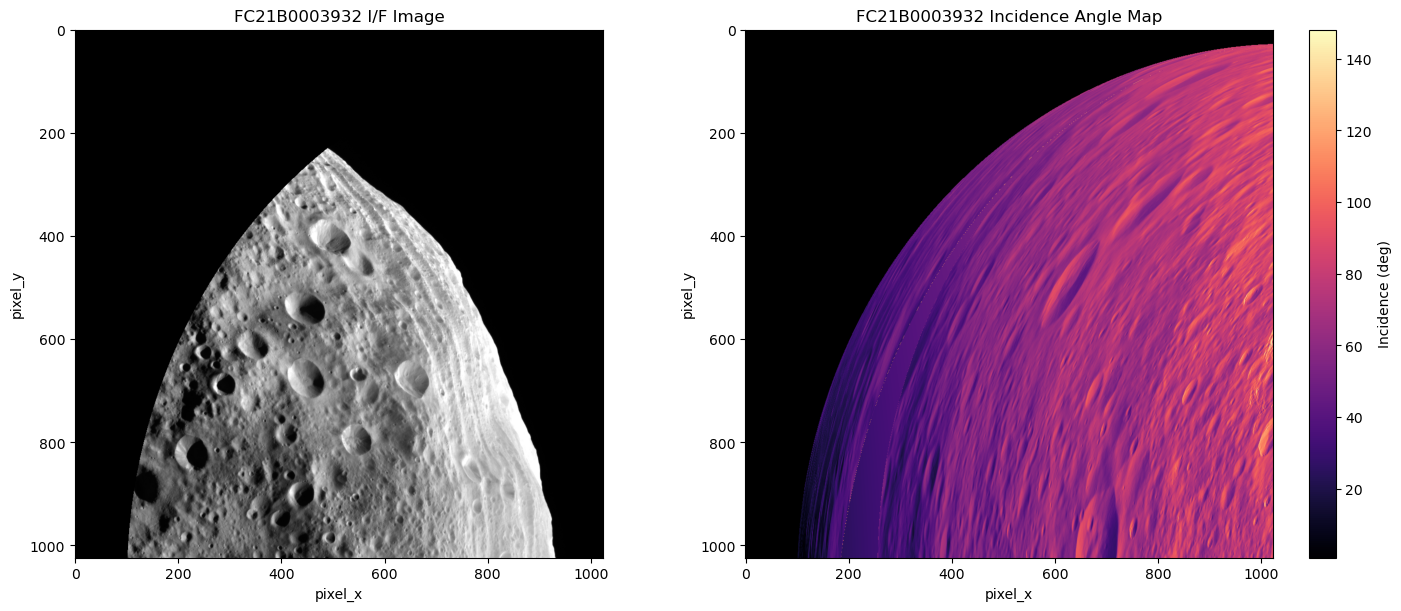

Valid asteroid pixels: 707,441 / 1,048,576 (67.5%)
Deep-space pixels are masked in black.


In [3]:
# Spatial sanity check for a specific image: FC21B0003932_11223181943F1F
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

parquet_path = Path("../data/04_geometry_tables/FC21B0003932_11223181943F1F_geometry.parquet")
if not parquet_path.exists():
    raise FileNotFoundError(f"Missing parquet: {parquet_path}")

df_fc = pd.read_parquet(parquet_path)
print(f"Loaded {parquet_path.name} with {len(df_fc):,} rows")

h, w = 1024, 1024
iof_grid = np.full((h, w), np.nan, dtype=np.float32)
inc_grid = np.full((h, w), np.nan, dtype=np.float32)

# Rebuild from sparse flat table using pixel indices when present.
if {"pixel_x", "pixel_y"}.issubset(df_fc.columns):
    px = df_fc["pixel_x"].to_numpy(dtype=int)
    py = df_fc["pixel_y"].to_numpy(dtype=int)
    valid = (px >= 0) & (px < w) & (py >= 0) & (py < h)
    iof_grid[py[valid], px[valid]] = df_fc["iof"].to_numpy(dtype=np.float32)[valid]
    inc_grid[py[valid], px[valid]] = df_fc["incidence"].to_numpy(dtype=np.float32)[valid]
else:
    expected = h * w
    if len(df_fc) != expected:
        raise ValueError(
            f"No pixel coordinates and row count={len(df_fc)} cannot reshape to 1024x1024."
        )
    iof_grid = df_fc["iof"].to_numpy(dtype=np.float32).reshape(h, w)
    inc_grid = df_fc["incidence"].to_numpy(dtype=np.float32).reshape(h, w)

# Deep-space pixels (NaN) shown in black to avoid scaling artifacts.
iof_ma = np.ma.masked_invalid(iof_grid)
inc_ma = np.ma.masked_invalid(inc_grid)

iof_cmap = plt.cm.get_cmap("gray").copy()
iof_cmap.set_bad("black")
inc_cmap = plt.cm.get_cmap("magma").copy()
inc_cmap.set_bad("black")

iof_vmax = np.nanpercentile(iof_grid, 99)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axes[0].imshow(iof_ma, cmap=iof_cmap, origin="upper", vmin=0.0, vmax=iof_vmax)
axes[0].set_title("FC21B0003932 I/F Image")
axes[0].set_xlabel("pixel_x")
axes[0].set_ylabel("pixel_y")

im1 = axes[1].imshow(inc_ma, cmap=inc_cmap, origin="upper")
axes[1].set_title("FC21B0003932 Incidence Angle Map")
axes[1].set_xlabel("pixel_x")
axes[1].set_ylabel("pixel_y")
cbar = fig.colorbar(im1, ax=axes[1])
cbar.set_label("Incidence (deg)")

plt.show()

covered = np.isfinite(inc_grid).sum()
print(f"Valid asteroid pixels: {covered:,} / {h * w:,} ({covered / (h * w):.1%})")
print("Deep-space pixels are masked in black.")

In [20]:
import pandas as pd

parquet_path = Path(
    "/home/kaushim07/photometry_mcmc_env/data/04_geometry_tables/FC21B0003933_11223182603F1F_geometry.parquet"
)

df = pd.read_parquet(parquet_path)
display(df)
print("Actual columns in this file:")
print(df.columns.tolist())

# Also, show the first two rows so we can see the values
display(df.head(2))

,pixel_x,pixel_y,iof,incidence,emission,phase
0,287,0,2.082440,34.318851,78.658554,83.311890
1,288,0,2.926482,27.388462,84.696648,83.306549
2,289,0,1.923590,36.112217,62.813145,83.301208
3,290,0,1.439810,29.587851,74.162308,83.295868
4,291,0,2.158406,28.266760,80.566727,83.290520
...,...,...,...,...,...,...
845729,1019,1023,0.011882,77.967094,30.431513,79.395271
845730,1020,1023,0.011914,81.320648,28.959108,79.389938
845731,1021,1023,0.008041,80.849548,29.041317,79.384605
845732,1022,1023,0.010971,81.092270,28.558504,79.379272


Actual columns in this file:
['pixel_x', 'pixel_y', 'iof', 'incidence', 'emission', 'phase']


,pixel_x,pixel_y,iof,incidence,emission,phase
0,287,0,2.082440,34.318851,78.658554,83.311890
1,288,0,2.926482,27.388462,84.696648,83.306549


In [9]:
import numpy as np
import pandas as pd

# 1. Physical Limits Check (The Day/Night and Camera-View Line)
# We use 89.0 and 85.0 to stay away from the 'noisy' limb/terminator
df_phys = df[(df["incidence"] < 89.0) & (df["emission"] < 85.0)].copy()

# 2. Spherical Triangle Inequality Check
# Physics dictates: |inc - emi| <= phase <= inc + emi
# We add a small 0.1 degree tolerance for floating point errors
lower_bound = np.abs(df_phys["incidence"] - df_phys["emission"]) - 0.1
upper_bound = (df_phys["incidence"] + df_phys["emission"]) + 0.1

triangle_mask = (df_phys["phase"] >= lower_bound) & (df_phys["phase"] <= upper_bound)
df_final = df_phys[triangle_mask].copy()

# 3. Final Report
original_total = len(df)
night_side_dropped = original_total - len(df_phys)
geometry_violations = len(df_phys) - len(df_final)

print("--- FINAL PHYSICS AUDIT ---")
print(f"Original Pixels:       {original_total}")
print(f"Pixels in Darkness:    {night_side_dropped} (REMOVED)")
print(f"Triangle Violations:   {geometry_violations} (REMOVED)")
print(f"Clean Science Pixels:  {len(df_final)}")
print("-" * 27)
print(f"Final Max Incidence:   {df_final['incidence'].max():.2f}°")
print(f"Final Max Emission:    {df_final['emission'].max():.2f}°")

# 4. Preview the data ready for MCMC
df_final.head()

--- FINAL PHYSICS AUDIT ---
Original Pixels:       845734
Pixels in Darkness:    26859 (REMOVED)
Triangle Violations:   0 (REMOVED)
Clean Science Pixels:  818875
---------------------------
Final Max Incidence:   89.00°
Final Max Emission:    85.00°


,pixel_x,pixel_y,iof,incidence,emission,phase
0,287,0,2.082440,34.318851,78.658554,83.311890
1,288,0,2.926482,27.388462,84.696648,83.306549
2,289,0,1.923590,36.112217,62.813145,83.301208
3,290,0,1.439810,29.587851,74.162308,83.295868
4,291,0,2.158406,28.266760,80.566727,83.290520


In [10]:
# 1. Calculate the Lommel-Seeliger Disk Function
# This corrects for the 'shape' of Vesta
i_rad = np.radians(df_final["incidence"])
e_rad = np.radians(df_final["emission"])

mu0 = np.cos(i_rad)
mu = np.cos(e_rad)

# Disk function (Lommel-Seeliger)
disk_func = mu0 / (mu + mu0)

# 2. Apply normalization
df_final["reflectance_ls"] = df_final["iof"] / disk_func

# 3. Create a clean sample for the plot (1.0M points is too many for a plot)
df_sample = df_final.sample(n=20000, random_state=42)

print("Calculation complete. Ready to replicate Li et al.")

Calculation complete. Ready to replicate Li et al.


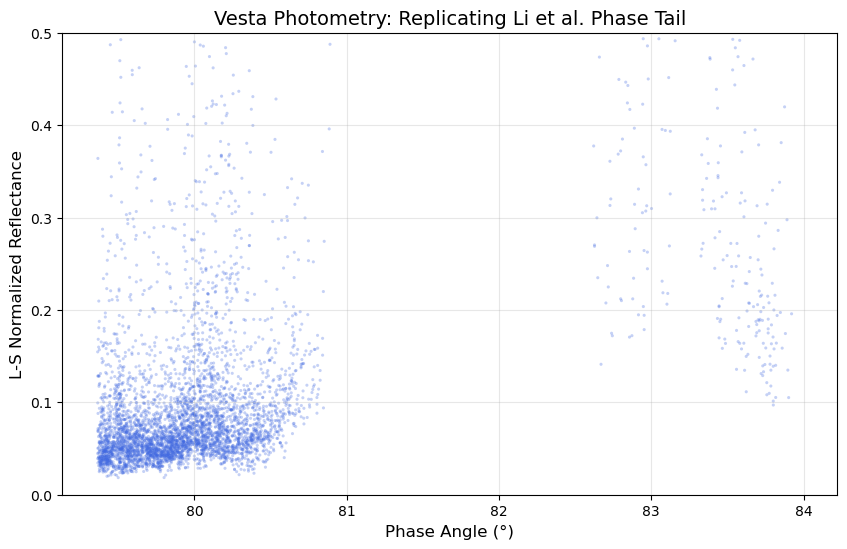

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_sample["phase"],
    df_sample["reflectance_ls"],
    s=5,
    alpha=0.3,
    color="royalblue",
    edgecolors="none",
)

plt.xlabel("Phase Angle (°)", fontsize=12)
plt.ylabel("L-S Normalized Reflectance", fontsize=12)
plt.title("Vesta Photometry: Replicating Li et al. Phase Tail", fontsize=14)
plt.grid(True, alpha=0.3)

# Usually Li et al. set the Y-axis to show the albedo clearly
plt.ylim(0, 0.5)

plt.show()

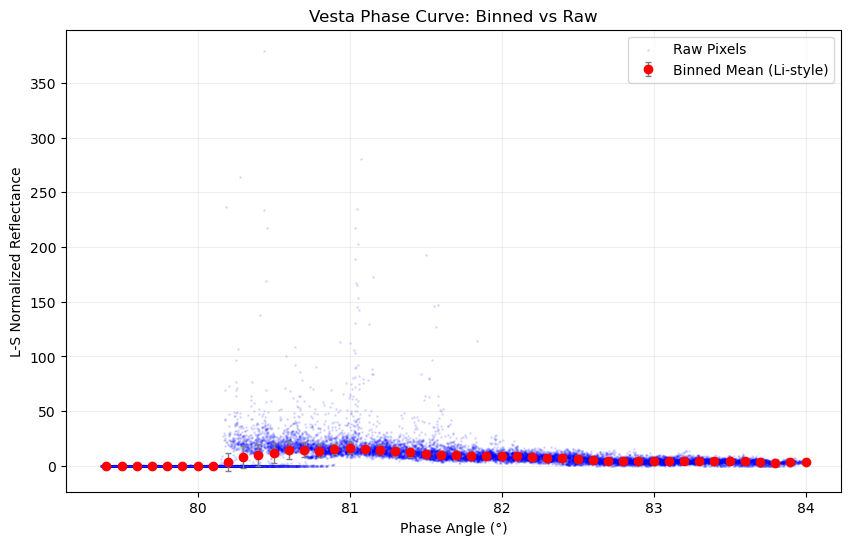

In [21]:
import matplotlib.pyplot as plt

# Ensure df_strict exists even if cells were run out of order.
if "df_strict" not in globals():
    df_strict = df_final.copy()

# 1. Create phase bins (e.g., 0.1 degree steps)
df_strict["phase_bin"] = df_strict["phase"].round(1)

# 2. Calculate mean and standard deviation for each bin
binned = (
    df_strict.groupby("phase_bin")["reflectance_ls"].agg(["mean", "std", "count"]).reset_index()
)

# 3. Plot it
plt.figure(figsize=(10, 6))
plt.errorbar(
    binned["phase_bin"],
    binned["mean"],
    yerr=binned["std"],
    fmt="o",
    color="red",
    ecolor="gray",
    elinewidth=1,
    capsize=2,
    label="Binned Mean (Li-style)",
)
plt.scatter(
    df_sample["phase"],
    df_sample["reflectance_ls"],
    s=1,
    alpha=0.1,
    color="blue",
    label="Raw Pixels",
)

plt.xlabel("Phase Angle (°)")
plt.ylabel("L-S Normalized Reflectance")
plt.title("Vesta Phase Curve: Binned vs Raw")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

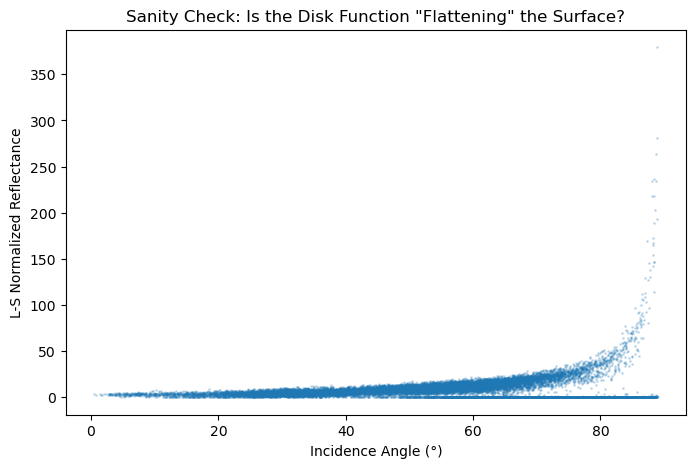

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df_sample["incidence"], df_sample["reflectance_ls"], s=1, alpha=0.2)
plt.xlabel("Incidence Angle (°)")
plt.ylabel("L-S Normalized Reflectance")
plt.title('Sanity Check: Is the Disk Function "Flattening" the Surface?')
plt.show()

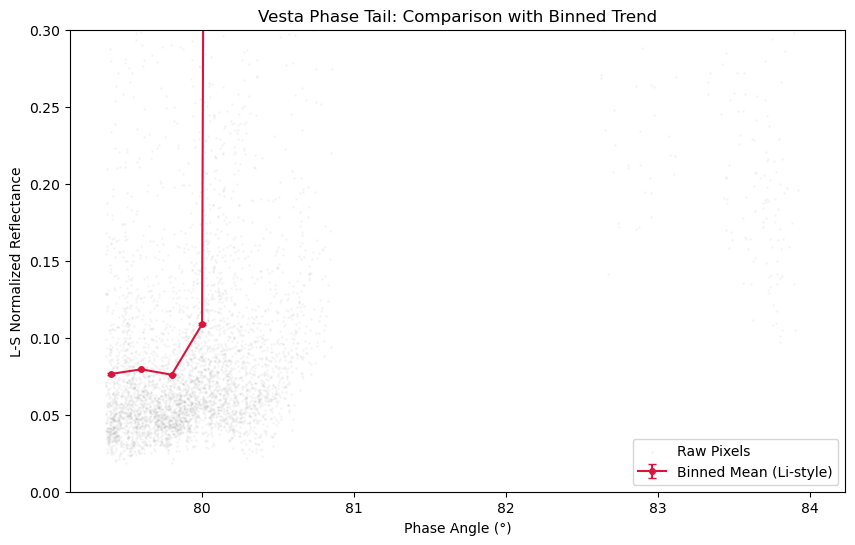

In [14]:
import matplotlib.pyplot as plt

# 1. Create 0.2-degree phase bins
df_final["phase_bin"] = (df_final["phase"] * 5).round() / 5

# 2. Group by bin and calculate the mean and standard error
stats = df_final.groupby("phase_bin")["reflectance_ls"].agg(["mean", "std", "count"]).reset_index()
stats["sem"] = stats["std"] / np.sqrt(stats["count"])  # Standard Error

# 3. The "Publication Ready" Plot
plt.figure(figsize=(10, 6))

# Plot the raw scatter in the background (faint)
plt.scatter(
    df_sample["phase"],
    df_sample["reflectance_ls"],
    s=1,
    alpha=0.05,
    color="gray",
    label="Raw Pixels",
)

# Plot the Binned Trend (The "Paper" line)
plt.errorbar(
    stats["phase_bin"],
    stats["mean"],
    yerr=stats["sem"],
    fmt="-o",
    color="crimson",
    markersize=4,
    capsize=3,
    label="Binned Mean (Li-style)",
)

plt.xlabel("Phase Angle (°)")
plt.ylabel("L-S Normalized Reflectance")
plt.title("Vesta Phase Tail: Comparison with Binned Trend")
plt.legend()
plt.ylim(0, 0.3)  # Tighten the Y-axis to see the trend
plt.show()

In [15]:
# 1. Apply a stricter 'Science Cut' (Standard for Li et al. type analysis)
# We exclude the 'Deep Shadows' and 'Limb' where the math explodes
df_strict = df_final[(df_final["incidence"] < 75.0) & (df_final["emission"] < 75.0)].copy()

# 2. Re-calculate your Binned Mean with the clean data
df_strict["phase_bin"] = df_strict["phase"].round(1)
stats_strict = (
    df_strict.groupby("phase_bin")["reflectance_ls"].agg(["mean", "std", "count"]).reset_index()
)

print(f"Pixels remaining after strict cut: {len(df_strict)}")
print(f"New Max Reflectance: {df_strict['reflectance_ls'].max():.4f}")

Pixels remaining after strict cut: 705684
New Max Reflectance: 37.2889


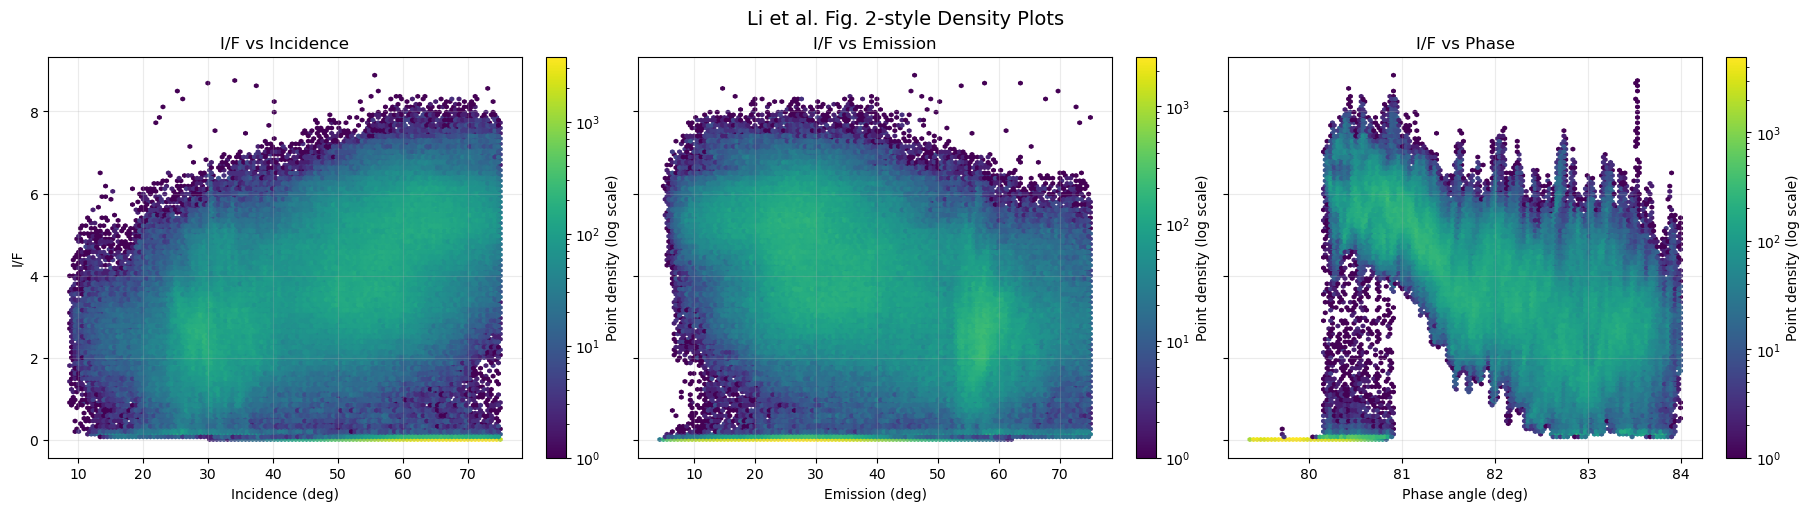

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# Assumes df_strict already exists with columns:
# incidence, emission, phase, iof

# Keep only finite and physically valid values
cols = ["incidence", "emission", "phase", "iof"]
d = df_strict[cols].replace([np.inf, -np.inf], np.nan).dropna()
d = d[d["iof"] > 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True, sharey=True)

pairs = [
    ("incidence", "I/F vs Incidence", "Incidence (deg)"),
    ("emission", "I/F vs Emission", "Emission (deg)"),
    ("phase", "I/F vs Phase", "Phase angle (deg)"),
]

for ax, (xcol, title, xlabel) in zip(axes, pairs, strict=False):
    hb = ax.hexbin(
        d[xcol],
        d["iof"],
        gridsize=120,
        mincnt=1,
        cmap="viridis",
        norm=LogNorm(),  # logarithmic density scale
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(alpha=0.25)

    cbar = fig.colorbar(hb, ax=ax)
    cbar.set_label("Point density (log scale)")

axes[0].set_ylabel("I/F")
fig.suptitle("Li et al. Fig. 2-style Density Plots", fontsize=14)
plt.show()

Valid fit points: 705,684 / 705,684
Minnaert A (albedo): 4.299237 ± 0.016942
Minnaert k (limb-darkening): 0.907330 ± 0.004732
RMSE: 2.208835
R^2:  -0.242356


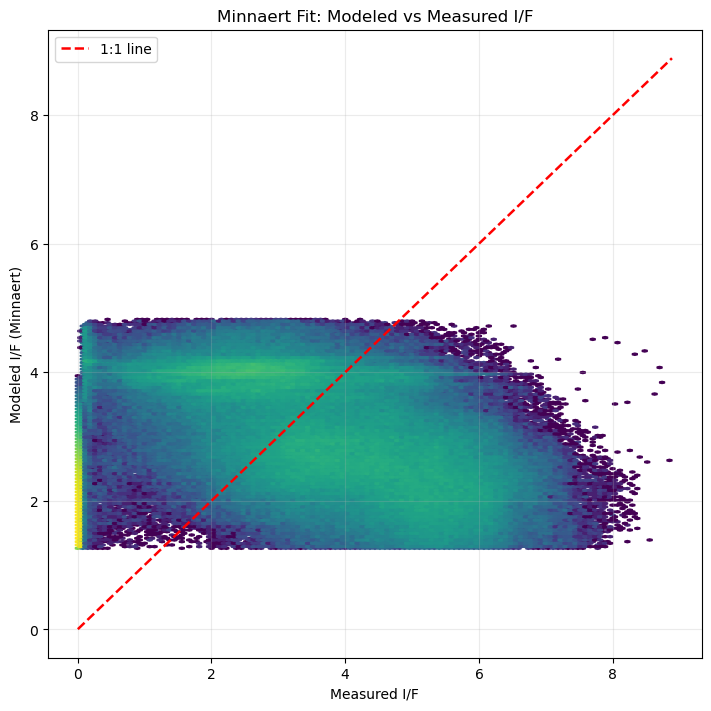

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

required_cols = ["incidence", "emission", "phase", "iof"]
missing = [c for c in required_cols if c not in df_strict.columns]
if missing:
    raise KeyError(f"df_strict is missing required columns: {missing}")

# Build clean fitting table
fit_df = df_strict[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

# Convert angles from degrees to radians
inc_rad = np.deg2rad(fit_df["incidence"].to_numpy(dtype=np.float64))
emi_rad = np.deg2rad(fit_df["emission"].to_numpy(dtype=np.float64))
iof_measured = fit_df["iof"].to_numpy(dtype=np.float64)

mu0 = np.cos(inc_rad)  # cos(i)
mu = np.cos(emi_rad)  # cos(e)

# Keep physically valid sunlit/viewable geometry for Minnaert fitting
valid = (
    np.isfinite(mu0)
    & np.isfinite(mu)
    & np.isfinite(iof_measured)
    & (iof_measured > 0.0)
    & (mu0 > 0.0)
    & (mu > 0.0)
)
mu0_fit = mu0[valid]
mu_fit = mu[valid]
iof_fit = iof_measured[valid]

if len(iof_fit) < 50:
    raise ValueError(f"Not enough valid points for robust Minnaert fit: {len(iof_fit)}")


def minnaert_model(x, A, k):
    m0, m = x
    return A * (m0**k) * (m ** (k - 1.0))


# Initial guesses and physically sensible bounds
A0 = float(np.nanmedian(iof_fit))
k0 = 1.0
p0 = (max(A0, 1e-6), k0)
bounds = ([1e-12, 0.0], [10.0, 2.0])

params, cov = curve_fit(
    minnaert_model,
    (mu0_fit, mu_fit),
    iof_fit,
    p0=p0,
    bounds=bounds,
    maxfev=200000,
)
A_fit, k_fit = params

# Parameter uncertainties (1-sigma)
perr = np.sqrt(np.diag(cov)) if np.all(np.isfinite(cov)) else np.array([np.nan, np.nan])
A_err, k_err = perr

# Predicted I/F for all cleaned rows
fit_df["modeled_iof"] = minnaert_model((mu0, mu), A_fit, k_fit)

# Goodness-of-fit on valid subset
modeled_valid = minnaert_model((mu0_fit, mu_fit), A_fit, k_fit)
resid = iof_fit - modeled_valid
rmse = float(np.sqrt(np.mean(resid**2)))
ss_res = float(np.sum(resid**2))
ss_tot = float(np.sum((iof_fit - np.mean(iof_fit)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

print(f"Valid fit points: {len(iof_fit):,} / {len(fit_df):,}")
print(f"Minnaert A (albedo): {A_fit:.6f} ± {A_err:.6f}")
print(f"Minnaert k (limb-darkening): {k_fit:.6f} ± {k_err:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2:  {r2:.6f}")

# Scatter: Modeled I/F vs Measured I/F (Li et al.-style goodness-of-fit diagnostic)
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.hexbin(
    iof_fit,
    modeled_valid,
    gridsize=120,
    bins="log",
    mincnt=1,
    cmap="viridis",
)

line_min = float(min(np.min(iof_fit), np.min(modeled_valid)))
line_max = float(max(np.max(iof_fit), np.max(modeled_valid)))
ax.plot([line_min, line_max], [line_min, line_max], "r--", lw=1.8, label="1:1 line")

ax.set_xlabel("Measured I/F")
ax.set_ylabel("Modeled I/F (Minnaert)")
ax.set_title("Minnaert Fit: Modeled vs Measured I/F")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.show()

Pixels used: 705,684
Incidence range: 8.74 to 75.00 deg
Emission range: 4.42 to 75.00 deg


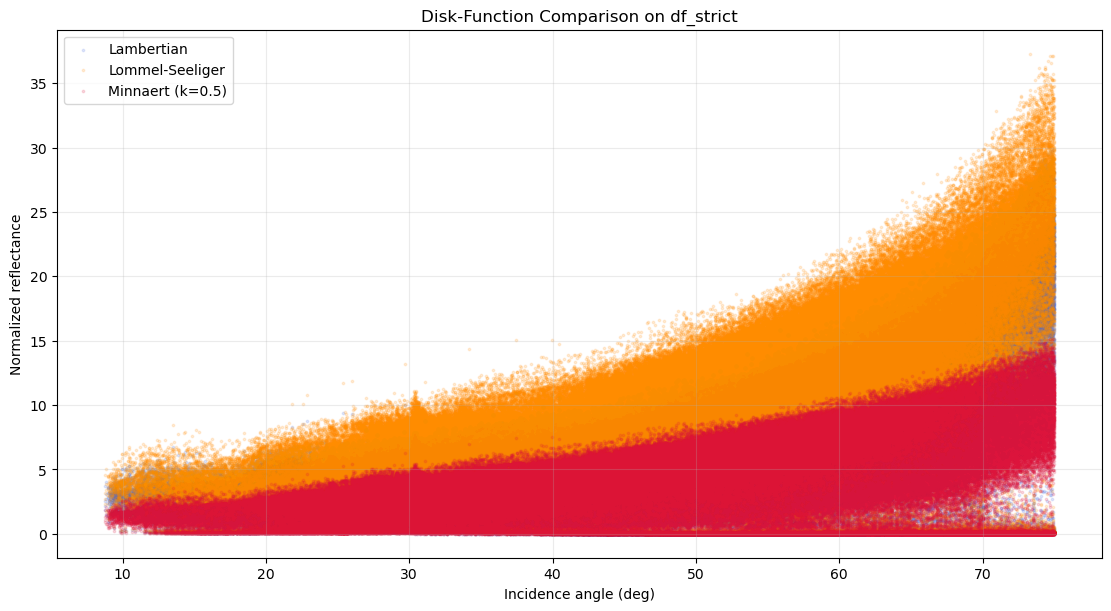

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Compare disk functions on df_strict to see which one flattens I/F best, Li et al.-style.
# Assumes df_strict already exists with columns: incidence, emission, phase, iof.
required_cols = ["incidence", "emission", "phase", "iof"]
missing_cols = [col for col in required_cols if col not in df_strict.columns]
if missing_cols:
    raise KeyError(f"df_strict is missing required columns: {missing_cols}")

df_disk = df_strict[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

# Convert angles to radians for trigonometric functions.
inc_rad = np.deg2rad(df_disk["incidence"].to_numpy(dtype=np.float64))
emi_rad = np.deg2rad(df_disk["emission"].to_numpy(dtype=np.float64))
iof = df_disk["iof"].to_numpy(dtype=np.float64)

mu0 = np.cos(inc_rad)
mu = np.cos(emi_rad)

# Keep only physically valid illuminated/viewable pixels.
valid = (iof > 0.0) & np.isfinite(mu0) & np.isfinite(mu) & (mu0 > 0.0) & (mu > 0.0)
df_disk = df_disk.loc[valid].copy()
mu0 = mu0[valid]
mu = mu[valid]
iof = iof[valid]

# Disk-function normalizations.
df_disk["ref_lambertian"] = iof / mu0
df_disk["ref_lommel"] = iof / (mu0 / (mu0 + mu))
df_disk["ref_minnaert"] = iof / ((mu0**0.5) * (mu ** (-0.5)))

# Sort for cleaner overplotted curves.
df_disk = df_disk.sort_values("incidence").reset_index(drop=True)

print(f"Pixels used: {len(df_disk):,}")
print(f"Incidence range: {df_disk['incidence'].min():.2f} to {df_disk['incidence'].max():.2f} deg")
print(f"Emission range: {df_disk['emission'].min():.2f} to {df_disk['emission'].max():.2f} deg")

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
ax.scatter(
    df_disk["incidence"],
    df_disk["ref_lambertian"],
    s=3,
    alpha=0.15,
    color="royalblue",
    label="Lambertian",
)
ax.scatter(
    df_disk["incidence"],
    df_disk["ref_lommel"],
    s=3,
    alpha=0.15,
    color="darkorange",
    label="Lommel-Seeliger",
)
ax.scatter(
    df_disk["incidence"],
    df_disk["ref_minnaert"],
    s=3,
    alpha=0.15,
    color="crimson",
    label="Minnaert (k=0.5)",
)

ax.set_xlabel("Incidence angle (deg)")
ax.set_ylabel("Normalized reflectance")
ax.set_title("Disk-Function Comparison on df_strict")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.show()